In [30]:
import math
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l

In [31]:
max_degree = 20  # 多项式的最大阶数
n_train, n_test = 100, 100  # 训练和测试数据集大小
true_w = np.zeros(max_degree)  # 分配大量的空间
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

features = np.random.normal(size=(n_train + n_test, 1))
np.random.shuffle(features)
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1)  # gamma(n)=(n-1)!
# labels的维度:(n_train+n_test,)
labels = np.dot(poly_features, true_w)
labels += np.random.normal(scale=0.1, size=labels.shape)

In [32]:
# NumPy ndarray转换为tensor
true_w, features, poly_features, labels = [torch.tensor(x, dtype=
    torch.float32) for x in [true_w, features, poly_features, labels]]

features[:2], poly_features[:2, :], labels[:2]

(tensor([[0.9425],
         [2.4136]]),
 tensor([[1.0000e+00, 9.4254e-01, 4.4419e-01, 1.3956e-01, 3.2885e-02, 6.1990e-03,
          9.7381e-04, 1.3112e-04, 1.5449e-05, 1.6179e-06, 1.5249e-07, 1.3066e-08,
          1.0263e-09, 7.4410e-11, 5.0096e-12, 3.1479e-13, 1.8544e-14, 1.0281e-15,
          5.3837e-17, 2.6707e-18],
         [1.0000e+00, 2.4136e+00, 2.9127e+00, 2.3433e+00, 1.4140e+00, 6.8255e-01,
          2.7456e-01, 9.4669e-02, 2.8561e-02, 7.6595e-03, 1.8487e-03, 4.0563e-04,
          8.1586e-05, 1.5147e-05, 2.6114e-06, 4.2018e-07, 6.3384e-08, 8.9990e-09,
          1.2067e-09, 1.5328e-10]]),
 tensor([ 5.3725, 11.1358]))

In [33]:
def evaluate_loss(net, data_iter, loss):  #@save
    """评估给定数据集上模型的损失"""
    metric = d2l.Accumulator(2)  # 损失的总和,样本数量
    for X, y in data_iter:
        out = net(X)
        y = y.reshape(out.shape)
        l = loss(out, y)
        metric.add(l.sum(), l.numel())
    return metric[0] / metric[1]

In [38]:
def train(train_features, test_features, train_labels, test_labels,
          num_epochs=400):
    loss = nn.MSELoss()
    input_shape = train_features.shape[-1]
    # 不设置偏置，因为我们已经在多项式中实现了它
    print(f"input_shape:==============")
    print(input_shape)
    net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))
    batch_size = min(10, train_labels.shape[0])
    train_iter = d2l.load_array((train_features, train_labels.reshape(-1,1)),
                                batch_size)
    test_iter = d2l.load_array((test_features, test_labels.reshape(-1,1)),
                               batch_size, is_train=False)
    trainer = torch.optim.SGD(net.parameters(), lr=0.01)
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', yscale='log',
                            xlim=[1, num_epochs], ylim=[1e-3, 1e2],
                            legend=['train', 'test'])
    for epoch in range(num_epochs):
        d2l.train_epoch_ch3(net, train_iter, loss, trainer)
        if epoch == 0 or (epoch + 1) % 20 == 0:
            animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss),
                                     evaluate_loss(net, test_iter, loss)))
    print('weight:', net[0].weight.data.numpy())
    print(input_shape)

weight: [[ 5.0191407  1.1718333 -3.4201717  5.6620455]]
4


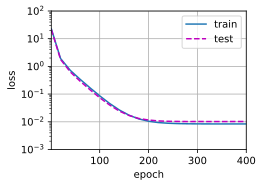

In [39]:
# 从多项式特征中选择前4个维度，即1,x,x^2/2!,x^3/3!
train(poly_features[:n_train, :4], poly_features[n_train:, :4],
      labels[:n_train], labels[n_train:])

weight: [[3.0841782 4.135885 ]]


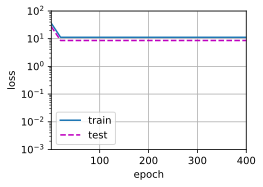

In [9]:
# 从多项式特征中选择前2个维度，即1和x
train(poly_features[:n_train, :2], poly_features[n_train:, :2],
      labels[:n_train], labels[n_train:])

weight: [[ 4.9951925   1.3323437  -3.3231096   5.1357865  -0.26789078  1.1052973
   0.12801453 -0.08231351  0.20805438 -0.08664593  0.0730339  -0.01167189
   0.12861662 -0.05504777 -0.02105488 -0.13478163 -0.06482489  0.0605717
  -0.01363123  0.13686475]]


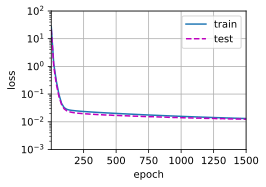

In [10]:
# 从多项式特征中选取所有维度
train(poly_features[:n_train, :], poly_features[n_train:, :],
      labels[:n_train], labels[n_train:], num_epochs=1500)

In [14]:
max_degree = 20  # 多项式的最大阶数
n_train, n_test = 100, 100  # 训练和测试数据集大小
true_w = np.zeros(max_degree)  # 分配大量的空间
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

features = np.random.normal(size=(n_train + n_test, 1))

In [16]:
len(features)

200

In [17]:
base = np.array([1,2,3,4])
exp = np.array([1,2,3,4])

In [19]:
result = np.power(base,exp)
result

array([  1,   4,  27, 256])

In [20]:
base = np.array([1,2,3,4])
result = np.power(base, 2)
result

array([ 1,  4,  9, 16])

In [21]:
features = np.array([[1],[2],[3],[4]])
degrees = np.array([[1,2,3,4]])
result = np.power(features, degrees)
result

array([[  1,   1,   1,   1],
       [  2,   4,   8,  16],
       [  3,   9,  27,  81],
       [  4,  16,  64, 256]])

In [22]:
import numpy as np

a = np.array([1, 2])
b = np.array([10, 20])

result = np.dot(a, b)

# 计算过程：(1 * 10) + (2 * 20) = 10 + 40 = 50
print(result) 
# 输出: 50

50


In [23]:
poly_features

tensor([[ 1.0000e+00, -4.0070e-02,  8.0279e-04,  ..., -4.9749e-39,
          1.1074e-41, -2.3822e-44],
        [ 1.0000e+00, -4.0624e-02,  8.2517e-04,  ..., -6.2852e-39,
          1.4185e-41, -3.0829e-44],
        [ 1.0000e+00, -6.7434e-01,  2.2737e-01,  ..., -3.4663e-18,
          1.2986e-19, -4.6089e-21],
        ...,
        [ 1.0000e+00,  5.8612e-01,  1.7177e-01,  ...,  3.1964e-19,
          1.0408e-20,  3.2107e-22],
        [ 1.0000e+00,  5.5707e-01,  1.5517e-01,  ...,  1.3472e-19,
          4.1695e-21,  1.2225e-22],
        [ 1.0000e+00, -1.5003e+00,  1.1255e+00,  ..., -2.7796e-12,
          2.3168e-13, -1.8294e-14]])

In [24]:
poly_features.shape

torch.Size([200, 20])

In [25]:
poly_features[:3, :4]

tensor([[ 1.0000e+00, -4.0070e-02,  8.0279e-04, -1.0722e-05],
        [ 1.0000e+00, -4.0624e-02,  8.2517e-04, -1.1174e-05],
        [ 1.0000e+00, -6.7434e-01,  2.2737e-01, -5.1107e-02]])

In [26]:
labels

tensor([ 5.0303e+00,  4.9144e+00,  3.0115e+00,  5.2546e+00,  4.0273e-01,
         4.7384e+00,  6.6720e+00,  4.5504e+00, -7.6676e-01,  8.5168e+00,
        -1.2257e+01,  1.0058e+01, -4.0899e+00,  4.5995e+00,  5.2434e+00,
         5.7295e+00,  5.3952e+00,  2.9177e+00,  5.1927e+00,  6.4485e-01,
         5.2879e+00,  5.0396e+00,  3.6796e+00,  8.7697e+00,  5.3854e+00,
         5.1074e+00,  4.2991e+00,  5.0972e+00,  1.0566e+00,  5.2204e+00,
         1.9990e+00,  5.3336e+00,  7.0398e+00,  5.3727e+00,  5.0550e+00,
        -5.5594e-01,  3.0268e+00,  5.6362e+00,  5.4497e+00,  5.3924e+00,
         5.4252e+00,  5.2918e+00,  6.5556e+00,  7.7936e+00,  4.7998e+00,
         5.6397e+00,  6.2687e+00,  5.1710e+00, -1.7051e+00,  6.0627e+00,
         5.0990e+00,  5.1808e+00,  3.4234e+00, -1.2600e+01,  4.0927e+00,
        -7.2365e+00,  5.7203e+00,  2.5238e-01,  4.7309e+00,  2.4184e+00,
         4.5799e+00,  5.2261e+00,  5.5402e+00, -1.1798e+01,  5.4797e+00,
         4.1319e+00,  5.1172e+00,  1.1039e+00,  1.9

In [27]:
labels.shape

torch.Size([200])

In [29]:
input_shape = features.shape[-1]
input_shape

1

In [40]:
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05

In [41]:
true_w

tensor([[0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0.0100],
        [0

In [42]:
true_w.shape

torch.Size([200, 1])